# Week 3 - Day 12

# Logistic Regression Classification using Iris Dataset

---

## Internship

**Cooperative Tech Private Limited**

Artificial Intelligence & Machine Learning Internship

Week 3 - Day 12

---

## Notebook

01_logistic_regression.ipynb

---

## Objective

The objective of this notebook is to understand and implement the Logistic Regression Classification algorithm using the famous Iris Dataset.

In this notebook we will

- Load the dataset
- Explore the data
- Prepare the dataset
- Train a Logistic Regression model
- Predict flower species
- Evaluate model performance
- Visualize results
- Understand classification metrics

---

## Dataset

Dataset Name

Iris Dataset

Target Variable

Species

Features

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Machine Learning Task

**Multiclass Classification**

# Import Required Libraries

Before building a Machine Learning model, we need to import all the required Python libraries.

These libraries help us in

- Data Loading
- Data Processing
- Data Visualization
- Machine Learning
- Model Evaluation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Load Dataset

Now we will load the Iris Dataset using Pandas.

The dataset contains measurements of different flower species.

Our goal is to predict the flower species using the flower measurements.

In [6]:
df = pd.read_csv("../data/iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Dataset Information

Let's understand the dataset structure.

We will check

- Number of rows
- Number of columns
- Data types
- Missing values

In [7]:
print("Shape :", df.shape)

print()

df.info()

Shape : (150, 6)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


In [9]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

# Dataset Preview

Let's look at some random records from the dataset.

In [10]:
df.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
141,142,6.9,3.1,5.1,2.3,Iris-virginica
130,131,7.4,2.8,6.1,1.9,Iris-virginica
143,144,6.8,3.2,5.9,2.3,Iris-virginica
107,108,7.3,2.9,6.3,1.8,Iris-virginica
139,140,6.9,3.1,5.4,2.1,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
46,47,5.1,3.8,1.6,0.2,Iris-setosa
20,21,5.4,3.4,1.7,0.2,Iris-setosa
97,98,6.2,2.9,4.3,1.3,Iris-versicolor


# Target Variable

The target column is **Species**.

Let's check how many samples belong to each class.

In [11]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

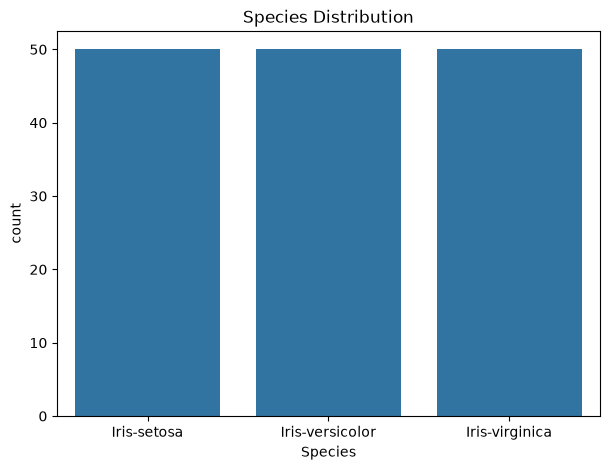

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,x="Species")

plt.title("Species Distribution")

plt.show()

# Feature Selection

Machine Learning models require

Features (X)

Target (Y)

Features are the input columns.

Species is the output column.

In [13]:
X = df.drop(columns=["Species","Id"])

y = df["Species"]

# Train-Test Split

The dataset is divided into

80% Training Data

20% Testing Data

Training data is used to train the model.

Testing data is used to evaluate the model.

In [14]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling

Logistic Regression performs better when numerical features are scaled.

We will use StandardScaler.

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Build Logistic Regression Model

In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

# Prediction

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test,y_pred)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 93.33%


# Classification Report

The classification report provides

- Precision
- Recall
- F1-score
- Support

In [19]:
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



# Confusion Matrix

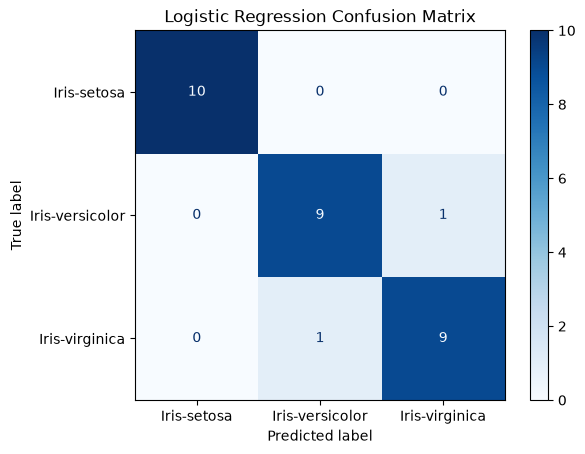

In [20]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Prediction Probabilities

Logistic Regression predicts probabilities for each class.

These probabilities show how confident the model is before making the final prediction.

In [21]:
probabilities = model.predict_proba(X_test)

pd.DataFrame(
    probabilities,
    columns=model.classes_
).head()

,Iris-setosa,Iris-versicolor,Iris-virginica
0,0.979355,0.020644,3.582230e-07
1,0.003773,0.369499,6.267280e-01
2,0.149647,0.841581,8.771707e-03
3,0.095889,0.894120,9.990573e-03
4,0.988808,0.011192,1.695524e-07


# Model Summary

Algorithm

- Logistic Regression

Dataset

- Iris Dataset

Classification Type

- Multi-class Classification

Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The Logistic Regression model successfully classified the Iris flower species with high accuracy and demonstrated strong performance across all evaluation metrics.

# Save Species Distribution Plot

The following chart shows the distribution of flower species in the Iris dataset.

The figure is saved inside the **images/** folder for documentation and GitHub README.

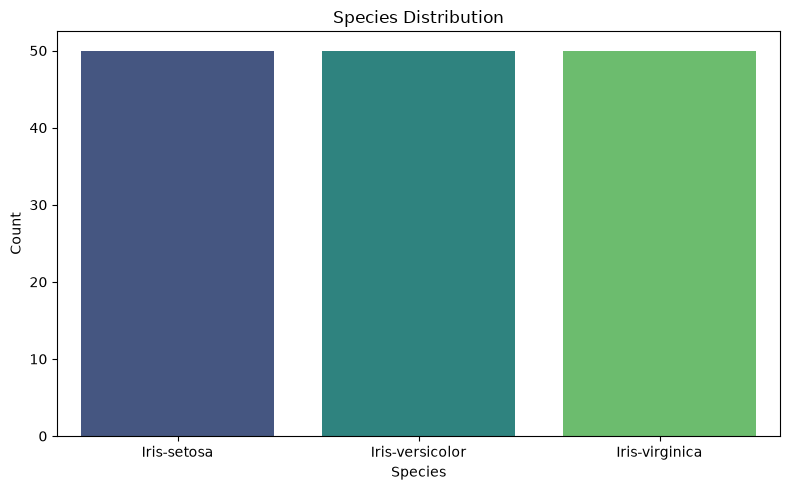

In [22]:
import os

# Create images folder if it doesn't exist
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Species",
    palette="viridis"
)

plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../images/species_distribution.png", dpi=300)

plt.show()

# Save Confusion Matrix

The confusion matrix helps us understand how well the Logistic Regression model classified each flower species.

The image is saved for documentation purposes.

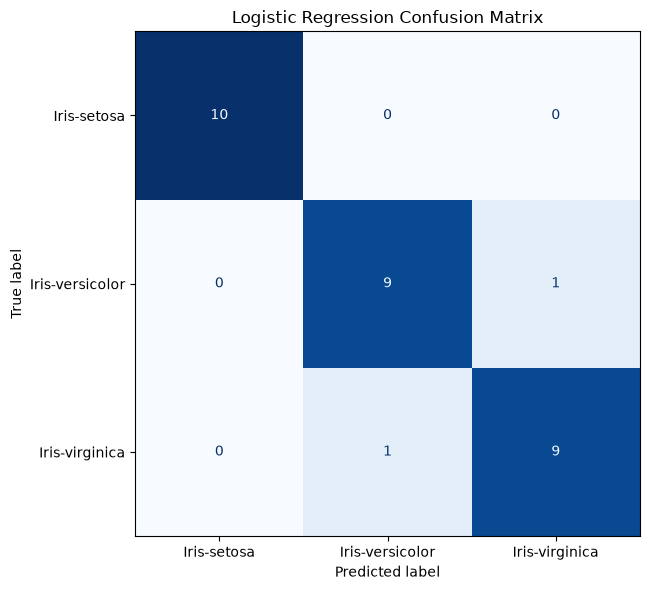

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix_logistic.png",
    dpi=300
)

plt.show()